# Проверка равенства дисперсий: тест Левене

Проверяем нулевую гипотезу:

**H0: дисперсии зарплатных ожиданий у мобильных и немобильных соискателей равны.**

Под мобильными понимаются соискатели, у которых выполнено хотя бы одно из условий:
- `business_trips == 1`;
- `relocation == 1`;
- `schedule_type_1 == 1`.

Для проверки используем **тест Левене**.

In [1]:
import math

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## 1. Загрузка данных и формирование групп

In [2]:
df = pd.read_csv("dataset_cleaned.csv")

for col in ["salary", "business_trips", "relocation", "schedule_type_1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["is_mobile"] = (
    df["business_trips"].eq(1)
    | df["relocation"].eq(1)
    | df["schedule_type_1"].eq(1)
)

mobile = df.loc[df["is_mobile"], "salary"].dropna().astype(float)
non_mobile = df.loc[~df["is_mobile"], "salary"].dropna().astype(float)

print("mobile size:", mobile.shape[0])
print("non_mobile size:", non_mobile.shape[0])

mobile size: 2630
non_mobile size: 40597


In [3]:
summary = pd.DataFrame({
    "count": [mobile.shape[0], non_mobile.shape[0]],
    "mean": [mobile.mean(), non_mobile.mean()],
    "median": [mobile.median(), non_mobile.median()],
    "variance": [mobile.var(ddof=1), non_mobile.var(ddof=1)],
    "std": [mobile.std(ddof=1), non_mobile.std(ddof=1)],
}, index=["mobile", "non_mobile"])

summary.round(2)

,count,mean,median,variance,std
mobile,2630,39859.84,30000.0,7.146893e+08,26733.67
non_mobile,40597,24361.88,20000.0,1.568806e+08,12525.20


## 2. Формулировка гипотез

- $H_0$: $\sigma^2_{mobile} = \sigma^2_{non\_mobile}$
- $H_1$: $\sigma^2_{mobile} \neq \sigma^2_{non\_mobile}$

Тест Левене проверяет именно равенство дисперсий.

## 3. Реализация теста Левене

В окружении проекта нет `scipy`, поэтому расчёт выполняется вручную.

Классический тест Левене строится на абсолютных отклонениях от среднего внутри каждой группы, а затем для них считается однофакторная ANOVA.

In [4]:
def betacf(a, b, x, max_iter=200, eps=3e-14):
    qab = a + b
    qap = a + 1.0
    qam = a - 1.0
    c = 1.0
    d = 1.0 - qab * x / qap
    if abs(d) < 1e-300:
        d = 1e-300
    d = 1.0 / d
    h = d

    for m in range(1, max_iter + 1):
        m2 = 2 * m

        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d
        if abs(d) < 1e-300:
            d = 1e-300
        c = 1.0 + aa / c
        if abs(c) < 1e-300:
            c = 1e-300
        d = 1.0 / d
        h *= d * c

        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d
        if abs(d) < 1e-300:
            d = 1e-300
        c = 1.0 + aa / c
        if abs(c) < 1e-300:
            c = 1e-300
        d = 1.0 / d
        delta = d * c
        h *= delta

        if abs(delta - 1.0) < eps:
            break

    return h


def regularized_incomplete_beta(a, b, x):
    if x <= 0.0:
        return 0.0
    if x >= 1.0:
        return 1.0

    ln_beta = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1.0 - x) - ln_beta)

    if x < (a + 1.0) / (a + b + 2.0):
        return bt * betacf(a, b, x) / a

    return 1.0 - bt * betacf(b, a, 1.0 - x) / b


def f_cdf(x, d1, d2):
    if x <= 0:
        return 0.0
    z = (d1 * x) / (d1 * x + d2)
    return regularized_incomplete_beta(d1 / 2.0, d2 / 2.0, z)


def levene_test_mean(*groups):
    groups = [pd.Series(group).dropna().astype(float) for group in groups]
    k = len(groups)
    ni = [len(group) for group in groups]
    N = sum(ni)

    deviations = [abs(group - group.mean()) for group in groups]
    dev_means = [dev.mean() for dev in deviations]
    grand_mean = sum(n * m for n, m in zip(ni, dev_means)) / N

    ss_between = sum(n * (m - grand_mean) ** 2 for n, m in zip(ni, dev_means))
    ss_within = sum(((dev - m) ** 2).sum() for dev, m in zip(deviations, dev_means))

    df1 = k - 1
    df2 = N - k
    ms_between = ss_between / df1
    ms_within = ss_within / df2
    statistic = ms_between / ms_within
    p_value = 1.0 - f_cdf(statistic, df1, df2)

    return {
        "statistic": statistic,
        "df1": df1,
        "df2": df2,
        "p_value": p_value,
    }

In [5]:
results = levene_test_mean(mobile, non_mobile)
alpha = 0.05

pd.Series({**results, "alpha": alpha}).to_frame("value")

,value
statistic,2048.999447
df1,1.000000
df2,43225.000000
p_value,0.000000
alpha,0.050000


In [6]:
p_value = results["p_value"]

if p_value == 0.0:
    p_value_text = "0.0 из-за машинного округления; фактически p-value крайне мало"
else:
    p_value_text = f"{p_value:.6e}"

print(f"Статистика Левене: {results['statistic']:.4f}")
print(f"df1: {results['df1']}")
print(f"df2: {results['df2']}")
print(f"p-value: {p_value_text}")

if p_value < alpha:
    print("Вывод: отвергаем H0 о равенстве дисперсий на уровне значимости 0.05.")
    print("Дисперсии зарплатных ожиданий у мобильных и немобильных соискателей статистически значимо различаются.")
else:
    print("Вывод: не отвергаем H0 о равенстве дисперсий на уровне значимости 0.05.")
    print("Недостаточно оснований считать, что дисперсии различаются.")

Статистика Левене: 2048.9994
df1: 1
df2: 43225
p-value: 0.0 из-за машинного округления; фактически p-value крайне мало
Вывод: отвергаем H0 о равенстве дисперсий на уровне значимости 0.05.
Дисперсии зарплатных ожиданий у мобильных и немобильных соискателей статистически значимо различаются.


## 4. Визуализация

График ниже помогает увидеть, что разброс зарплат у мобильных соискателей заметно выше.

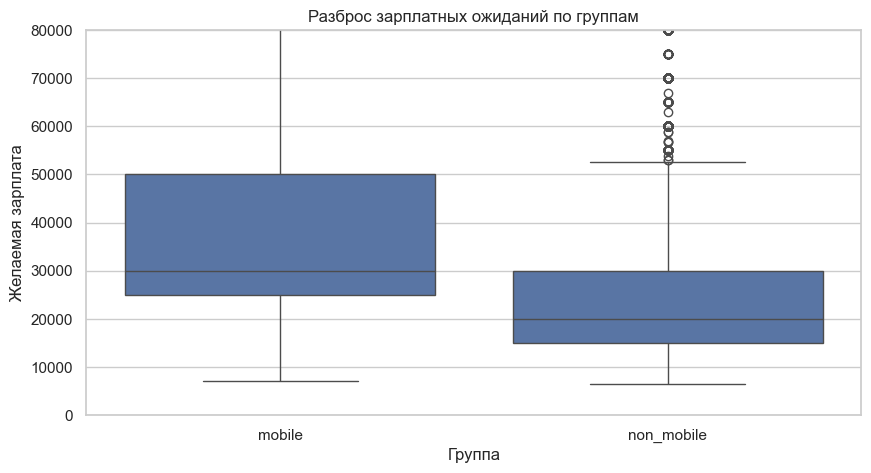

In [7]:
plot_df = pd.DataFrame({
    "salary": pd.concat([mobile, non_mobile], ignore_index=True),
    "group": ["mobile"] * len(mobile) + ["non_mobile"] * len(non_mobile),
})

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="group", y="salary")
plt.ylim(0, plot_df["salary"].quantile(0.99))
plt.title("Разброс зарплатных ожиданий по группам")
plt.xlabel("Группа")
plt.ylabel("Желаемая зарплата")
plt.show()

## 5. Итог

По тесту Левене нулевая гипотеза о равенстве дисперсий отвергается.

Это согласуется и с описательной статистикой: у мобильных соискателей вариативность зарплатных ожиданий существенно выше, чем у немобильных.